# Cardiovascular Risk Prediction Using Machine Learning — Framingham Heart Study

The Framingham Heart Study is one of the longest-running cardiovascular cohort studies, tracking patients over decades to identify key risk factors for coronary heart disease (CHD).
This project builds an end-to-end machine learning pipeline to predict an individual's 10-year CHD risk using clinical and demographic features from that dataset.

Pipeline overview:
- Exploratory data analysis and missing value handling
- Clinical feature engineering (interactions, risk groups, polynomial terms, blood pressure categories)
- Class imbalance handling via SMOTE-ENN resampling
- Multi-model training and 5-fold cross-validation(Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, SVM, KNN)
- Stacking ensemble from top-performing models
- Hyperparameter tuning via GridSearchCV
- Probability calibration (isotonic regression)
- Optimal threshold selection (Youden-J and F1-max)
- SHAP explainability for model interpretability
- Experiment tracking with MLflow
- Statistical benchmarking against the clinical
- Framingham Risk Score using DeLong's AUC test

Dataset : Framingham Heart Study (4,240 patients, 16 features)

Target  : 10-year coronary heart disease risk (binary)

In [1]:
# 1. INSTALL

!pip -q install imbalanced-learn xgboost lightgbm catboost shap mlflow scipy scikit-learn --upgrade -q

In [2]:
# 2. IMPORTS

import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import mlflow

from scipy import stats

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose           import ColumnTransformer
from sklearn.pipeline          import Pipeline
from imblearn.pipeline         import Pipeline as ImbPipeline
from imblearn.combine          import SMOTEENN
from imblearn.over_sampling    import SMOTE
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing     import OneHotEncoder, StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, StackingClassifier
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.calibration       import CalibratedClassifierCV, calibration_curve
from sklearn.metrics           import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 200)
RANDOM_STATE = 42

In [3]:
# 3. LOAD DATA

DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
df = pd.read_csv(DATA_URL)
print("Dataset Shape:", df.shape)

def clean_col(col):
    col = str(col).strip().lower()
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"[^a-zA-Z0-9_]", "", col)
    return col

df.columns = [clean_col(c) for c in df.columns]
TARGET = "tenyearchd"

Dataset Shape: (4240, 16)


In [4]:
# 4. EDA

print("Target distribution:")
display(df[TARGET].value_counts())
display(df[TARGET].value_counts(normalize=True))
print("\n Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

Target distribution:


,count
tenyearchd,
0,3596
1,644


,proportion
tenyearchd,
0,0.848113
1,0.151887



 Missing values:


,0
glucose,388
education,105
bpmeds,53
totchol,50
cigsperday,29
bmi,19
heartrate,1
male,0
prevalenthyp,0
prevalentstroke,0


In [5]:
# 5. FEATURE ENGINEERING

df["pulse_pressure"]          = pd.to_numeric(df["sysbp"],     errors="coerce") - pd.to_numeric(df["diabp"],    errors="coerce")
df["chol_age_interaction"]    = pd.to_numeric(df["totchol"],   errors="coerce") * pd.to_numeric(df["age"],      errors="coerce")
df["glucose_bmi_interaction"] = pd.to_numeric(df["glucose"],   errors="coerce") * pd.to_numeric(df["bmi"],      errors="coerce")
df["hr_age_interaction"]      = pd.to_numeric(df["heartrate"], errors="coerce") * pd.to_numeric(df["age"],      errors="coerce")
df["map"]                     = (pd.to_numeric(df["diabp"],    errors="coerce") * 2 +
                                  pd.to_numeric(df["sysbp"],   errors="coerce")) / 3
df["pack_years_proxy"]        = pd.to_numeric(df["cigsperday"], errors="coerce") / 20

for col in ["age", "sysbp", "totchol", "glucose"]:
    df[f"{col}_sq"] = pd.to_numeric(df[col], errors="coerce") ** 2

df["age_risk_group"] = pd.cut(pd.to_numeric(df["age"],  errors="coerce"),
    bins=[-np.inf, 30, 45, 60, np.inf],
    labels=["young", "adult", "mid_age", "senior"])
df["bmi_risk_group"] = pd.cut(pd.to_numeric(df["bmi"],  errors="coerce"),
    bins=[-np.inf, 18.5, 25, 30, np.inf],
    labels=["underweight", "normal", "overweight", "obese"])
df["bp_category"]    = pd.cut(pd.to_numeric(df["sysbp"], errors="coerce"),
    bins=[-np.inf, 120, 130, 140, np.inf],
    labels=["normal", "elevated", "stage1_htn", "stage2_htn"])

df = df.drop_duplicates().copy()
print(f"After feature engineering — Dataset Shape: {df.shape}")

After feature engineering — Dataset Shape: (4240, 29)


In [6]:
# 6. FRAMINGHAM RISK SCORE (clinical benchmark)

def _safe_float(val, default):
    try:
        v = float(val)
        return default if (np.isnan(v) or np.isinf(v)) else v
    except Exception:
        return default

def framingham_risk_score(row, sex_col="male"):
    """Wilson et al. 1998 / ATP-III 10-year CVD risk. Returns 0–1."""
    try:
        age   = max(_safe_float(row.get("age",    50),  50), 1)
        chol  = max(_safe_float(row.get("totchol",200), 200), 1)
        hdl   = max(_safe_float(row.get("hdl",    45),  45), 1)
        sbp   = max(_safe_float(row.get("sysbp",  120), 120), 1)
        smoke = _safe_float(row.get("currentsmoker", 0), 0)
        dm    = _safe_float(row.get("diabetes",      0), 0)
        is_m  = _safe_float(row.get(sex_col,         1), 1)
        if is_m >= 0.5:
            score = (3.06117*np.log(age) + 1.12370*np.log(chol)
                   - 0.93263*np.log(hdl) + 1.93303*np.log(sbp)
                   + 0.65451*smoke + 0.57367*dm - 23.9802)
        else:
            score = (2.32888*np.log(age) + 1.20904*np.log(chol)
                   - 0.70833*np.log(hdl) + 2.76157*np.log(sbp)
                   + 0.52873*smoke + 0.69154*dm - 26.1931)
        prob = 1 - 0.9145 ** np.exp(score)
        return float(np.clip(prob, 0.0, 1.0)) if np.isfinite(prob) else 0.15
    except Exception:
        return 0.15

In [7]:
# 7. SPLIT

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy().astype(int)

numeric_features     = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Numeric features: {len(numeric_features)} | Categorical: {len(categorical_features)}")

Train: (3392, 28) | Test: (848, 28)
Numeric features: 25 | Categorical: 3


In [8]:
# 8. FRAMINGHAM BENCHMARK

frs_proba = X_test.apply(framingham_risk_score, axis=1).values.astype(float)
frs_proba = np.clip(np.where(np.isfinite(frs_proba), frs_proba, 0.15), 0.0, 1.0)
frs_preds = (frs_proba >= 0.2).astype(int)
print(f"Framingham Risk Score — ROC-AUC: {roc_auc_score(y_test, frs_proba):.4f}")
print(classification_report(y_test, frs_preds, zero_division=0))

Framingham Risk Score — ROC-AUC: 0.6583
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       719
           1       0.24      0.40      0.30       129

    accuracy                           0.71       848
   macro avg       0.56      0.59      0.56       848
weighted avg       0.78      0.71      0.74       848



In [9]:
# 9. PREPROCESSING

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

In [10]:
# 10. RESAMPLER

try:
    sampler = SMOTEENN(random_state=RANDOM_STATE)
    # Quick fit-test to confirm it works on this data
    ImbPipeline([("pre", preprocessor), ("s", sampler)]).fit_resample(X_train, y_train)
    print("Using SMOTE-ENN")
except Exception:
    sampler = SMOTE(random_state=RANDOM_STATE)
    print("Falling back to SMOTE")

Using SMOTE-ENN


In [11]:
# 11. MODELS

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver="liblinear", class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_split=5, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=5, learning_rate=0.05,
        eval_metric="AUC", random_seed=RANDOM_STATE,
        verbose=0, auto_class_weights="Balanced"),
    "SVM": SVC(
        probability=True, kernel="rbf", C=1.0, gamma="scale",
        class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

In [12]:
# 12. CROSS-VALIDATION

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy", "precision": "precision", "recall": "recall",
    "f1": "f1", "roc_auc": "roc_auc", "avg_precision": "average_precision"
}

cv_results = []
print("Running 5-fold CV...")
for name, model in models.items():
    pipe   = ImbPipeline([("pre", preprocessor), ("samp", sampler), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        "Model":        name,
        "CV Accuracy":  np.mean(scores["test_accuracy"]),
        "CV Precision": np.mean(scores["test_precision"]),
        "CV Recall":    np.mean(scores["test_recall"]),
        "CV F1":        np.mean(scores["test_f1"]),
        "CV ROC-AUC":   np.mean(scores["test_roc_auc"]),
        "CV PR-AUC":    np.mean(scores["test_avg_precision"])
    })
    print(f"  ✔ {name:22s} — AUC: {cv_results[-1]['CV ROC-AUC']:.4f}")

cv_df = (pd.DataFrame(cv_results)
           .sort_values("CV ROC-AUC", ascending=False)
           .reset_index(drop=True))
print("\n CV Results:")
display(cv_df)

Running 5-fold CV...
  ✔ Logistic Regression    — AUC: 0.7228
  ✔ Random Forest          — AUC: 0.7048
  ✔ XGBoost                — AUC: 0.6994
  ✔ LightGBM               — AUC: 0.7004
  ✔ CatBoost               — AUC: 0.7051
  ✔ SVM                    — AUC: 0.6857
  ✔ KNN                    — AUC: 0.6572

 CV Results:


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,CV PR-AUC
0,Logistic Regression,0.622945,0.249219,0.732039,0.371586,0.722826,0.340629
1,CatBoost,0.737932,0.287058,0.479612,0.358208,0.705083,0.328745
2,Random Forest,0.683090,0.264185,0.607767,0.367912,0.704757,0.307288
3,LightGBM,0.733215,0.281300,0.477670,0.353312,0.700446,0.321422
4,XGBoost,0.694593,0.264277,0.565049,0.359767,0.699367,0.325046
5,SVM,0.640347,0.243568,0.646602,0.353470,0.685697,0.264108
6,KNN,0.526538,0.207028,0.749515,0.324404,0.657184,0.222941


In [13]:
# 13. STACKING ENSEMBLE

top3      = cv_df["Model"].head(3).tolist()
stack_clf = StackingClassifier(
    estimators=[(n, models[n]) for n in top3],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0),
    passthrough=False, cv=3, n_jobs=-1)
print(f"Stacking from top-3: {top3}")

Stacking from top-3: ['Logistic Regression', 'CatBoost', 'Random Forest']


In [14]:
# 14. HYPERPARAMETER TUNING

best_name = cv_df.iloc[0]["Model"]
print(f"Best model: {best_name}")

param_grids = {
    "Logistic Regression": {"model__C": [0.01,0.1,1,10], "model__penalty": ["l1","l2"]},
    "Random Forest":       {"model__n_estimators": [200,300], "model__max_depth": [None,5,10], "model__min_samples_split": [2,5]},
    "XGBoost":             {"model__n_estimators": [200,300], "model__max_depth": [3,4,5],     "model__learning_rate": [0.03,0.05,0.1]},
    "LightGBM":            {"model__n_estimators": [200,300], "model__max_depth": [4,5,6],     "model__learning_rate": [0.03,0.05,0.1]},
    "CatBoost":            {"model__iterations":   [200,300], "model__depth":     [4,5],       "model__learning_rate": [0.03,0.05]},
    "SVM":                 {"model__C": [0.1,1,10], "model__gamma": ["scale","auto"]},
    "KNN":                 {"model__n_neighbors": [3,5,7,9], "model__weights": ["uniform","distance"]}
}

grid = GridSearchCV(
    ImbPipeline([("pre", preprocessor), ("samp", sampler), ("model", models[best_name])]),
    param_grids.get(best_name, {}),
    scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1)

print(f"\n Tuning {best_name}...")
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV AUC:", round(grid.best_score_, 4))

Best model: Logistic Regression

 Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__C': 0.01, 'model__penalty': 'l2'}
Best CV AUC: 0.7291


In [15]:
# 15. INFERENCE PIPELINE (sampler-free)

# ImbPipeline runs SMOTE-ENN on every predict call too — corrupts inference.
# Extract the fitted preprocessor + model into a plain sklearn Pipeline.
fitted_pre   = grid.best_estimator_.named_steps["pre"]
fitted_model = grid.best_estimator_.named_steps["model"]
inference_pipe = Pipeline([("pre", fitted_pre), ("model", fitted_model)])
print("Inference pipeline ready")

Inference pipeline ready


In [16]:
# 16. PROBABILITY CALIBRATION

print("Calibrating probabilities (isotonic)...")
X_tr_tf = fitted_pre.transform(X_train)
X_tr_res, y_tr_res = sampler.fit_resample(X_tr_tf, y_train)
calibrated_model = CalibratedClassifierCV(fitted_model, method="isotonic", cv=None)
calibrated_model.fit(X_tr_res, y_tr_res)
calibrated_pipe = Pipeline([("pre", fitted_pre), ("model", calibrated_model)])
print("Calibration complete")

Calibrating probabilities (isotonic)...
Calibration complete


In [17]:
# 17. STACKING FIT

print("Fitting stacking ensemble...")
stack_imb = ImbPipeline([("pre", preprocessor), ("samp", sampler), ("model", stack_clf)])
stack_imb.fit(X_train, y_train)
stack_pipe = Pipeline([
    ("pre",   stack_imb.named_steps["pre"]),
    ("model", stack_imb.named_steps["model"])
])

Fitting stacking ensemble...


In [18]:
# 18. HELPER FUNCTIONS

def delong_roc_test(y_true, p1, p2):
    """DeLong 1988 two-sided AUC comparison. Returns (z, p-value)."""
    def _c(y, p):
        pos = p[y==1]; neg = p[y==0]; m, n = len(pos), len(neg)
        V10 = np.array([(np.sum(pi>neg) + 0.5*np.sum(pi==neg)) / n for pi in pos])
        V01 = np.array([(np.sum(pj<pos) + 0.5*np.sum(pj==pos)) / m for pj in neg])
        return np.mean(V10), np.var(V10,ddof=1)/m, np.var(V01,ddof=1)/n, V10, V01
    a1,s10_1,s01_1,V10_1,V01_1 = _c(y_true, p1)
    a2,s10_2,s01_2,V10_2,V01_2 = _c(y_true, p2)
    m = int(y_true.sum()); n = len(y_true) - m
    cov = np.cov(V10_1,V10_2)[0,1]/m + np.cov(V01_1,V01_2)[0,1]/n
    var = max(s10_1+s01_1+s10_2+s01_2-2*cov, 1e-10)
    z   = (a1-a2) / np.sqrt(var)
    return z, 2*(1 - stats.norm.cdf(abs(z)))

def bootstrap_ci(y_true, y_proba, n_boot=500, seed=42):
    """Bootstrap 95% CI for ROC-AUC."""
    rng = np.random.default_rng(seed); scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        try: scores.append(roc_auc_score(y_true[idx], y_proba[idx]))
        except: pass
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def auto_thresholds(y_true, y_proba):
    """Return Youden-J and F1-maximising thresholds."""
    fpr, tpr, thr = roc_curve(y_true, y_proba)
    t_youden = float(thr[np.argmax(tpr - fpr)])
    prec, rec, t_pr = precision_recall_curve(y_true, y_proba)
    f1s   = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
    t_f1  = float(t_pr[np.argmax(f1s)])
    return t_youden, t_f1

def evaluate(name, pipe, X_te, y_te):
    """Evaluate a fitted inference pipeline and print a report."""
    proba = pipe.predict_proba(X_te)[:, 1]
    preds = pipe.predict(X_te)
    auc   = roc_auc_score(y_te, proba)
    lo, hi = bootstrap_ci(np.array(y_te), proba)
    print(f"\n{'='*54}\n  {name}\n{'='*54}")
    print(f"  ROC-AUC : {auc:.4f}  [95% CI: {lo:.4f}–{hi:.4f}]")
    print(f"  PR-AUC  : {average_precision_score(y_te,proba):.4f}  "
          f"|  Brier: {brier_score_loss(y_te,proba):.4f}")
    print(f"  F1: {f1_score(y_te,preds,zero_division=0):.4f}  "
          f"|  Recall: {recall_score(y_te,preds,zero_division=0):.4f}  "
          f"|  Acc: {accuracy_score(y_te,preds):.4f}")
    print(classification_report(y_te, preds, zero_division=0))
    return dict(
        name=name, proba=proba, preds=preds,
        auc=auc, prauc=average_precision_score(y_te,proba),
        brier=brier_score_loss(y_te,proba),
        f1=f1_score(y_te,preds,zero_division=0),
        rec=recall_score(y_te,preds,zero_division=0),
        acc=accuracy_score(y_te,preds),
        lo=lo, hi=hi
    )

In [19]:
# 19. EVALUATE

results = {}
results["Tuned"]      = evaluate(f"Tuned {best_name}",      inference_pipe,  X_test, y_test)
results["Calibrated"] = evaluate(f"Calibrated {best_name}", calibrated_pipe, X_test, y_test)
results["Stacking"]   = evaluate("Stacking Ensemble",       stack_pipe,      X_test, y_test)
results["FRS"]        = dict(
    name="Framingham Risk Score", proba=frs_proba, preds=frs_preds,
    auc=roc_auc_score(y_test,frs_proba),
    prauc=average_precision_score(y_test,frs_proba),
    brier=brier_score_loss(y_test,frs_proba),
    f1=f1_score(y_test,frs_preds,zero_division=0),
    rec=recall_score(y_test,frs_preds,zero_division=0),
    acc=accuracy_score(y_test,frs_preds),
    lo=None, hi=None)


  Tuned Logistic Regression
  ROC-AUC : 0.6915  [95% CI: 0.6447–0.7387]
  PR-AUC  : 0.2836  |  Brier: 0.2492
  F1: 0.3313  |  Recall: 0.6279  |  Acc: 0.6144
              precision    recall  f1-score   support

           0       0.90      0.61      0.73       719
           1       0.23      0.63      0.33       129

    accuracy                           0.61       848
   macro avg       0.56      0.62      0.53       848
weighted avg       0.80      0.61      0.67       848


  Calibrated Logistic Regression
  ROC-AUC : 0.6938  [95% CI: 0.6465–0.7407]
  PR-AUC  : 0.2762  |  Brier: 0.3122
  F1: 0.3327  |  Recall: 0.7287  |  Acc: 0.5554
              precision    recall  f1-score   support

           0       0.92      0.52      0.67       719
           1       0.22      0.73      0.33       129

    accuracy                           0.56       848
   macro avg       0.57      0.63      0.50       848
weighted avg       0.81      0.56      0.62       848


  Stacking Ensemble
  RO

In [20]:
# 20. DELONG TESTS

y_arr = np.array(y_test)
z1, p1 = delong_roc_test(y_arr, results["Tuned"]["proba"], results["Stacking"]["proba"])
print(f"DeLong — Tuned vs Stacking: z={z1:.3f}, p={p1:.4f}")
winner = "Tuned" if (p1 >= 0.05 or results["Tuned"]["auc"] >= results["Stacking"]["auc"]) else "Stacking"
print(f"Winner: {winner}")

z2, p2 = delong_roc_test(y_arr, results[winner]["proba"], results["FRS"]["proba"])
sig = "significantly" if p2 < 0.05 else "NOT significantly"
print(f"DeLong — {winner} vs FRS: z={z2:.3f}, p={p2:.4f}")
print(f"ML model {sig} outperforms Framingham RS")

DeLong — Tuned vs Stacking: z=3.615, p=0.0003
Winner: Tuned
DeLong — Tuned vs FRS: z=2.491, p=0.0128
ML model significantly outperforms Framingham RS


In [21]:
# 21. AUTO THRESHOLD

print(f"Optimal thresholds for {winner}:")
t_youden, t_f1 = auto_thresholds(y_arr, results[winner]["proba"])
print(f"Youden-J: {t_youden:.3f}  |  F1-max: {t_f1:.3f}")
for label, t in [("Youden-J", t_youden), ("F1-max", t_f1)]:
    yt = (results[winner]["proba"] >= t).astype(int)
    print(f"\n  [{label} @ {t:.3f}]")
    print(classification_report(y_arr, yt, zero_division=0))

Optimal thresholds for Tuned:
Youden-J: 0.602  |  F1-max: 0.602

  [Youden-J @ 0.602]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       719
           1       0.27      0.58      0.37       129

    accuracy                           0.70       848
   macro avg       0.59      0.65      0.59       848
weighted avg       0.81      0.70      0.74       848


  [F1-max @ 0.602]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       719
           1       0.27      0.58      0.37       129

    accuracy                           0.70       848
   macro avg       0.59      0.65      0.59       848
weighted avg       0.81      0.70      0.74       848



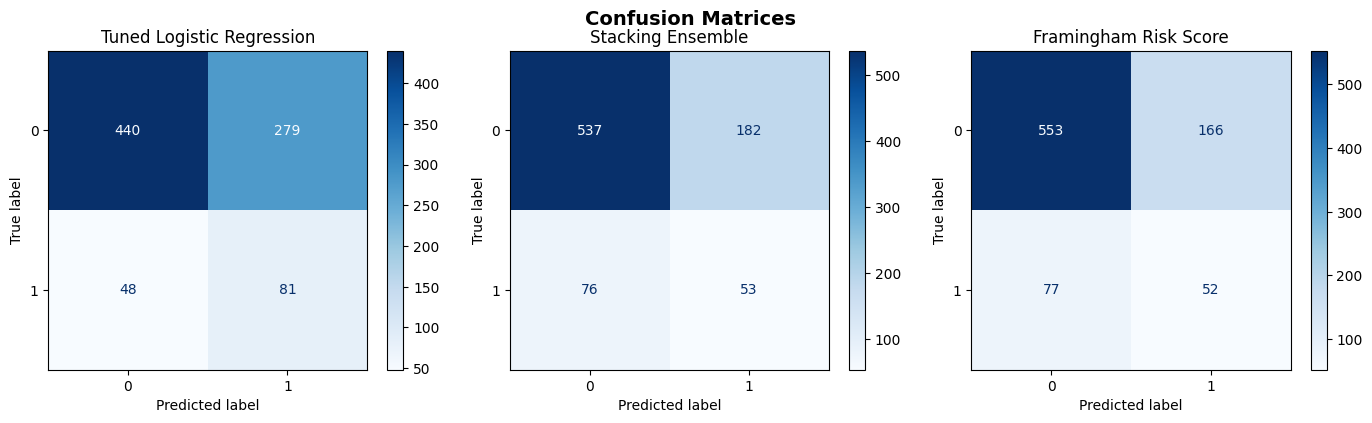

In [22]:
# 22. VISUALISATIONS

# Confusion matrices — Tuned, Stacking, FRS
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (key, title) in zip(axes, [
        ("Tuned",    f"Tuned {best_name}"),
        ("Stacking", "Stacking Ensemble"),
        ("FRS",      "Framingham Risk Score")]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, results[key]["preds"], ax=ax, cmap="Blues")
    ax.set_title(title)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

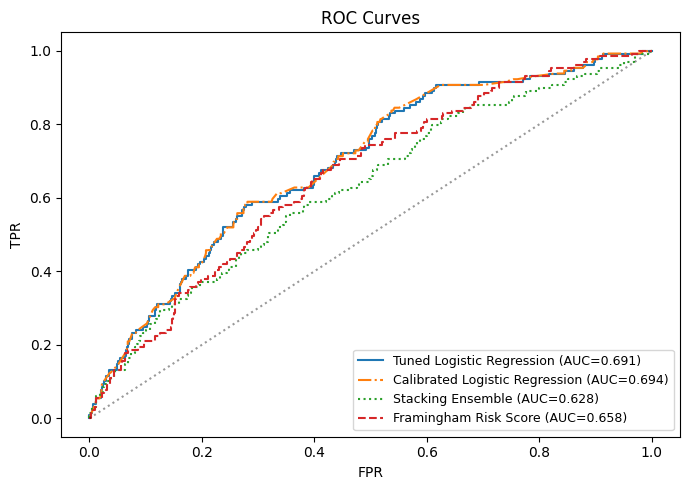

In [23]:
# ROC curves
plt.figure(figsize=(7, 5))
for key, ls in [("Tuned","-"), ("Calibrated","-."), ("Stacking",":"), ("FRS","--")]:
    fpr, tpr, _ = roc_curve(y_test, results[key]["proba"])
    plt.plot(fpr, tpr, ls=ls,
             label=f"{results[key]['name']} (AUC={results[key]['auc']:.3f})")
plt.plot([0,1],[0,1],"k:",alpha=.4)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

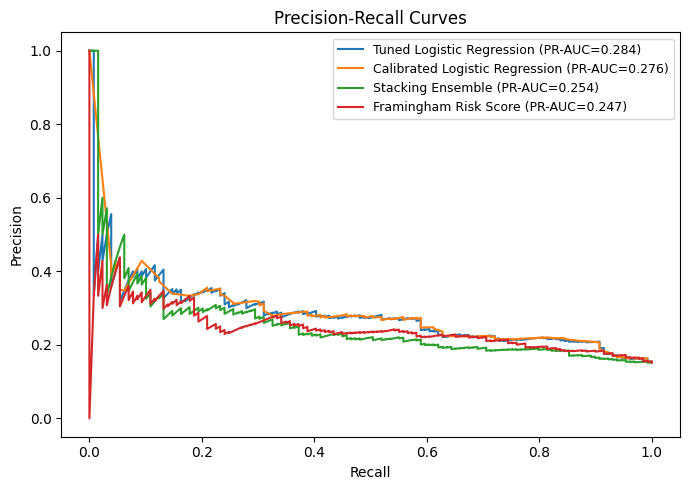

In [24]:
# Precision-Recall curves
plt.figure(figsize=(7, 5))
for key in ["Tuned", "Calibrated", "Stacking", "FRS"]:
    pc, rc, _ = precision_recall_curve(y_test, results[key]["proba"])
    plt.plot(rc, pc, label=f"{results[key]['name']} (PR-AUC={results[key]['prauc']:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curves")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

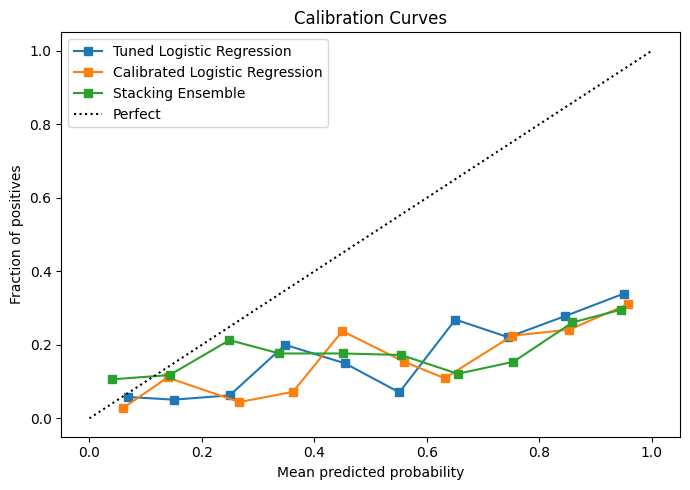

In [25]:
# Calibration curves
plt.figure(figsize=(7, 5))
for key in ["Tuned", "Calibrated", "Stacking"]:
    fp, mp = calibration_curve(y_test, results[key]["proba"], n_bins=10)
    plt.plot(mp, fp, "s-", label=results[key]["name"])
plt.plot([0,1],[0,1],"k:",label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives")
plt.title("Calibration Curves"); plt.legend(); plt.tight_layout(); plt.show()

Metrics comparison:


,Model,ROC-AUC,PR-AUC,F1,Recall,Brier
0,Tuned Logistic Regression,0.6915,0.2836,0.3313,0.6279,0.2492
1,Calibrated Logistic Regression,0.6938,0.2762,0.3327,0.7287,0.3122
2,Stacking Ensemble,0.6284,0.2544,0.2912,0.4109,0.2268
3,Framingham Risk Score,0.6583,0.2468,0.2997,0.4031,0.1274


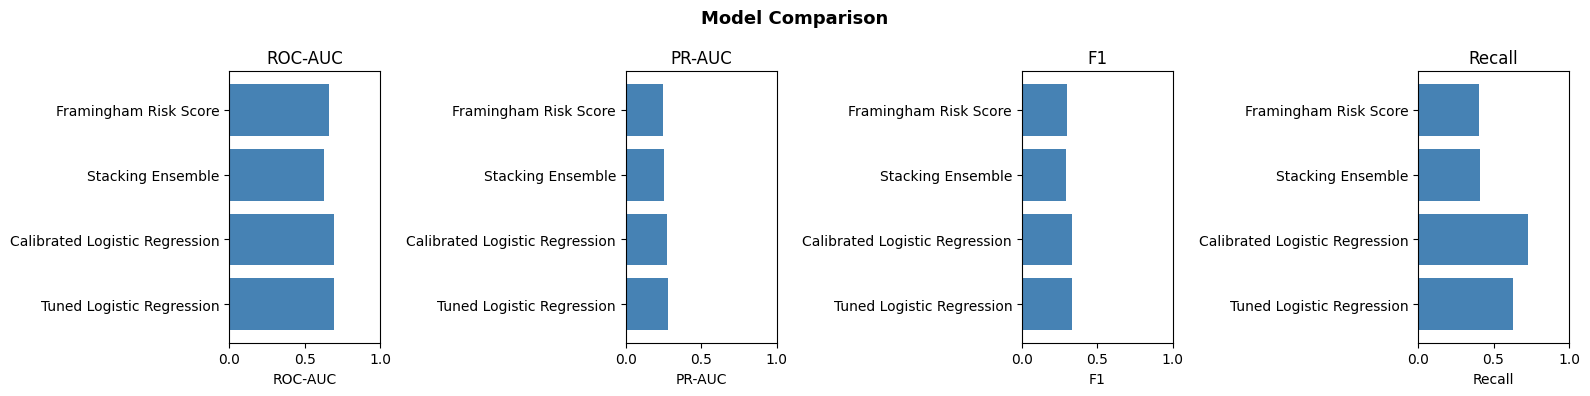

In [26]:
# Metrics comparison bar chart
summary_df = pd.DataFrame([{
    "Model":   r["name"],
    "ROC-AUC": r["auc"],
    "PR-AUC":  r["prauc"],
    "F1":      r["f1"],
    "Recall":  r["rec"],
    "Brier":   r["brier"]
} for r in results.values()])
print("Metrics comparison:")
display(summary_df.round(4))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m in zip(axes, ["ROC-AUC", "PR-AUC", "F1", "Recall"]):
    ax.barh(summary_df["Model"], summary_df[m], color="steelblue")
    ax.set_xlabel(m); ax.set_title(m); ax.set_xlim(0, 1)
plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

Generating SHAP explanations...
Using KernelExplainer (slower)...


  0%|          | 0/100 [00:00<?, ?it/s]

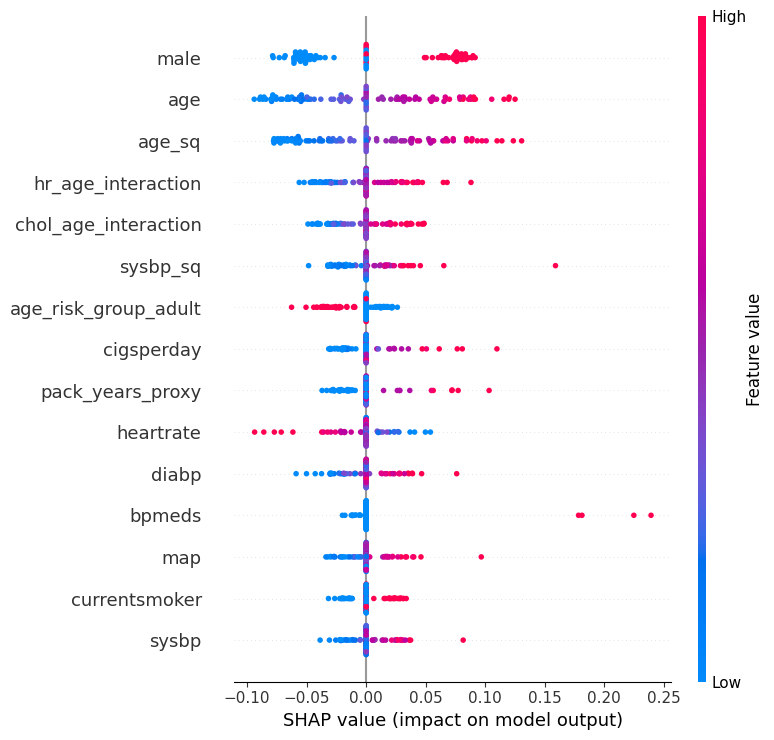

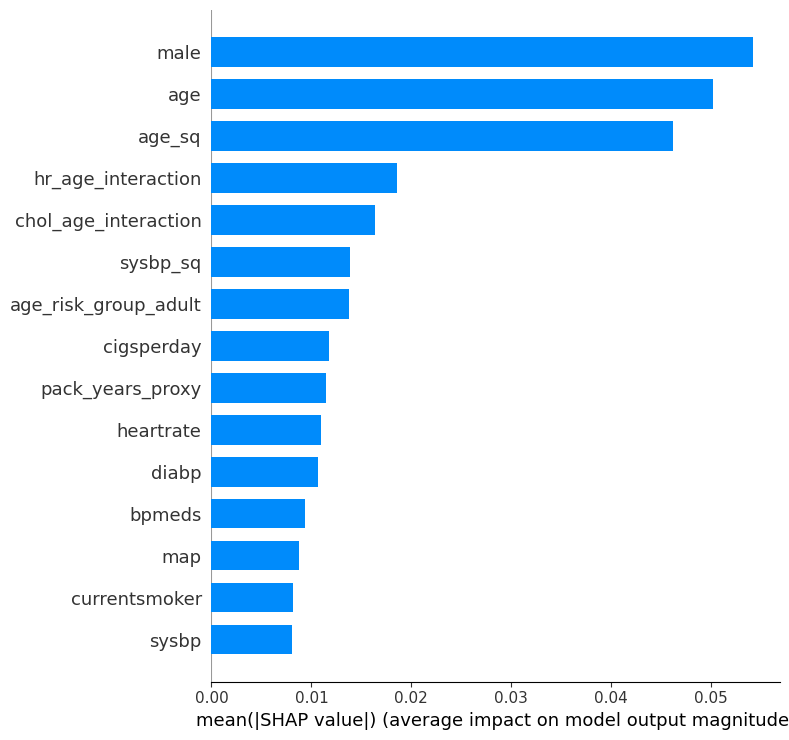

KernelExplainer SHAP complete


In [27]:
# 23. SHAP EXPLAINABILITY

print("Generating SHAP explanations...")

X_test_tf      = inference_pipe.named_steps["pre"].transform(X_test)
model_for_shap = inference_pipe.named_steps["model"]

# Build feature names to match transformed column count
feat_names = list(numeric_features)
try:
    ohe = (inference_pipe.named_steps["pre"]
                         .named_transformers_["cat"]
                         .named_steps["onehot"])
    feat_names += ohe.get_feature_names_out(categorical_features).tolist()
except Exception:
    pass
if len(feat_names) != X_test_tf.shape[1]:
    feat_names = [f"f{i}" for i in range(X_test_tf.shape[1])]

if best_name in ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]:
    explainer   = shap.TreeExplainer(model_for_shap)
    shap_vals   = explainer.shap_values(X_test_tf)
    sv          = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
    base_val    = (explainer.expected_value[1]
                   if isinstance(explainer.expected_value, (list, np.ndarray))
                   else explainer.expected_value)

    plt.figure(figsize=(9, 5))
    shap.summary_plot(sv, X_test_tf, feature_names=feat_names, max_display=20, show=False)
    plt.tight_layout(); plt.show()
    plt.figure(figsize=(9, 5))
    shap.summary_plot(sv, X_test_tf, feature_names=feat_names,
                      plot_type="bar", max_display=20, show=False)
    plt.tight_layout(); plt.show()

    pos_idx  = int(np.where(y_arr == 1)[0][0])
    shap_exp = shap.Explanation(values=sv[pos_idx], base_values=base_val,
                                data=X_test_tf[pos_idx], feature_names=feat_names)
    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(shap_exp, max_display=15, show=False)
    plt.tight_layout(); plt.show()

    try:
        force = shap.force_plot(base_val, sv[pos_idx],
                                X_test_tf[pos_idx], feature_names=feat_names)
        shap.save_html("shap_force_plot.html", force)
        print("SHAP force plot → shap_force_plot.html")
    except Exception as e:
        print(f"Force plot skipped: {e}")

else:  # LR / SVM — KernelExplainer
    print("Using KernelExplainer (slower)...")
    bg       = shap.kmeans(inference_pipe.named_steps["pre"].transform(X_train), 50)
    explainer = shap.KernelExplainer(model_for_shap.predict_proba, bg)
    sample    = X_test_tf[:100]
    sv_all    = explainer.shap_values(sample, nsamples=200)
    if isinstance(sv_all, list):           sv = sv_all[1]
    elif sv_all.ndim == 3:                 sv = sv_all[:, :, 1]
    else:                                  sv = sv_all
    if sv.shape != sample.shape:
        sv = np.array(sv).reshape(sample.shape)
    plt.figure(figsize=(9, 5))
    shap.summary_plot(sv, sample, feature_names=feat_names, max_display=15, show=False)
    plt.tight_layout(); plt.show()
    plt.figure(figsize=(9, 5))
    shap.summary_plot(sv, sample, feature_names=feat_names,
                      plot_type="bar", max_display=15, show=False)
    plt.tight_layout(); plt.show()

    print("KernelExplainer SHAP complete")

In [28]:
# 24. MLFLOW TRACKING

print("Logging to MLflow...")
mlflow.set_experiment("heart_disease_prediction")
for key in ["Tuned", "Calibrated", "Stacking"]:
    r = results[key]
    with mlflow.start_run(run_name=r["name"]):
        mlflow.log_param("model",       r["name"])
        mlflow.log_param("best_base",   best_name)
        mlflow.log_metric("roc_auc",    r["auc"])
        mlflow.log_metric("pr_auc",     r["prauc"])
        mlflow.log_metric("brier",      r["brier"])
        mlflow.log_metric("f1",         r["f1"])
        mlflow.log_metric("recall",     r["rec"])
        mlflow.log_metric("auc_ci_lo",  r["lo"])
        mlflow.log_metric("auc_ci_hi",  r["hi"])
print("MLflow logging complete")

Logging to MLflow...
MLflow logging complete


In [29]:
# 25. SAVE MODEL

joblib.dump(inference_pipe,  "heart_disease_inference.pkl")
joblib.dump(calibrated_pipe, "heart_disease_calibrated.pkl")
joblib.dump(stack_pipe,      "heart_disease_stacking.pkl")
print("Saved: inference.pkl | calibrated.pkl | stacking.pkl")

Saved: inference.pkl | calibrated.pkl | stacking.pkl


In [30]:
# 26. FINAL SUMMARY

print("\n" + "="*58)
print("  FINAL SUMMARY")
print("="*58)
display(summary_df.round(4))
print(f"\n  Winner            : {results[winner]['name']}")
print(f"  ROC-AUC           : {results[winner]['auc']:.4f}"
      f"  [95% CI: {results[winner]['lo']:.4f}–{results[winner]['hi']:.4f}]")
print(f"  PR-AUC            : {results[winner]['prauc']:.4f}")
print(f"  Brier Score       : {results[winner]['brier']:.4f}")
print(f"  Youden-J threshold: {t_youden:.3f}")
print(f"  F1-max threshold  : {t_f1:.3f}")
print(f"  FRS Benchmark AUC : {results['FRS']['auc']:.4f}")
print(f"  ML vs FRS (DeLong): z={z2:.3f}, p={p2:.4f} — {sig} better")


  FINAL SUMMARY


,Model,ROC-AUC,PR-AUC,F1,Recall,Brier
0,Tuned Logistic Regression,0.6915,0.2836,0.3313,0.6279,0.2492
1,Calibrated Logistic Regression,0.6938,0.2762,0.3327,0.7287,0.3122
2,Stacking Ensemble,0.6284,0.2544,0.2912,0.4109,0.2268
3,Framingham Risk Score,0.6583,0.2468,0.2997,0.4031,0.1274



  Winner            : Tuned Logistic Regression
  ROC-AUC           : 0.6915  [95% CI: 0.6447–0.7387]
  PR-AUC            : 0.2836
  Brier Score       : 0.2492
  Youden-J threshold: 0.602
  F1-max threshold  : 0.602
  FRS Benchmark AUC : 0.6583
  ML vs FRS (DeLong): z=2.491, p=0.0128 — significantly better
